# 목표
- 2023.01 ~ 2024.12 데이터 기반, 25.7월 이후 가맹점이 어려워지는 순간(매출 급락, 폐업) 감지할 수 있는 AI 조기 경보 시스템
- 보유한 데이터는 2013.01~2024.12 뿐
- 매출건수/매출액 감소할 때, 이전의 핵심 요인은 뭐냐?
- 이진분류
- 회귀모델(폐업확률)
- 집단군 (고위험군)

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(palette='pastel')

pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)

In [42]:
# 한글 폰트 출력
import matplotlib.font_manager as fm

# 설치된 폰트 출력
font_list = [font.name for font in fm.fontManager.ttflist]
font_list

plt.rcParams['font.family'] = 'Pretendard'

In [43]:
# 데이터 불러오기
merchant_df = pd.read_csv('../data/raw/big_data_set1_f.csv', encoding='cp949')
sale_df = pd.read_csv('../data/raw/big_data_set2_f.csv', encoding='cp949')
cust_df = pd.read_csv('../data/raw/big_data_set3_f.csv', encoding='cp949')

In [44]:
# 데이터 크기 확인
print(f'merchant_df 크기: {merchant_df.shape}')
print(f'sale_df 크기: {sale_df.shape}')
print(f'cust_df 크기: {cust_df.shape}')

merchant_df 크기: (4185, 9)
sale_df 크기: (86590, 15)
cust_df 크기: (86590, 17)


In [45]:
# merchant_df 컬럼명 변경
merchant_df.columns = ['mct_id', 'mct_address', 'mct_name', 'brand_code', 'sigungu', 'industry_name', 'commercial_area', 'open_date', 'close_date']

In [46]:
merchant_df

,mct_id,mct_address,mct_name,brand_code,sigungu,industry_name,commercial_area,open_date,close_date
0,16184E93D9,서울 성동구 마장동,성우**,NaN,서울 성동구,축산물,마장동,20130320,NaN
1,4D039EA8B7,서울 성동구 마장동,대보**,NaN,서울 성동구,축산물,마장동,20131122,NaN
2,0074C4990A,서울 성동구 마장동,대용**,NaN,서울 성동구,축산물,마장동,20140512,NaN
3,68308F2746,서울 성동구 마장동,통일**,NaN,서울 성동구,축산물,마장동,20151124,NaN
4,4117EDDE9C,서울 성동구 마장동,한울**,NaN,서울 성동구,축산물,마장동,20151211,NaN
...,...,...,...,...,...,...,...,...,...
4180,7FCF23E6F3,서울특별시 성동구 마장로 137,아이**********,NaN,서울 성동구,아이스크림/빙수,NaN,20230821,NaN
4181,9743B78531,서울 성동구 독서당로 223,어반**,NaN,서울 성동구,양식,NaN,20130305,NaN
4182,C2261977A8,서울특별시 성동구 마장로35길 76,한성**,NaN,서울 성동구,축산물,NaN,20230517,NaN
4183,F1C69918DF,서울 성동구 왕십리로 410,국수**,한식-국수/만두3,서울 성동구,한식-국수/만두,NaN,20211007,NaN


### 가맹점 개요 정보
- **mct_id**: 가맹점 구분번호
- **mct_address**: 가맹점주소
- **mct_name**: 가맹점명 (앞 2글자 이후 마스킹처리, 2글자면 앞 1자리만, 1글자면 전부 마스킹)
- **brand_code**: 브랜드구분코드 (동일 브랜드 매장 식별 위한 구분 코드) => 동일한 브랜드 나타냄 ex) 비비큐는 치킨2
- **sigungu**: 가맹점지역
- **industry_name**: 업종
- **commercial_area**: 상권
- **open_date**: 개설일
- **close_date**: 폐업일

In [47]:
# sale_df 컬럼명 변경
sale_df.columns = ['mct_id', 'trans_date', 'operation_band', 'sale_amt_band', 'sale_cnt_band', 'unique_customer_band', 'aov_band', 'cancel_rate_band', 'delivery_sale_amount_ratio', 'industry_sale_amt_ratio', 'industry_sale_cnt_ratio',
                   'industry_sale_rank_pct', 'area_sale_rank_pct', 'industry_close_pct', 'area_close_pct']

In [48]:
sale_df.head()

,mct_id,trans_date,operation_band,sale_amt_band,sale_cnt_band,unique_customer_band,aov_band,cancel_rate_band,delivery_sale_amount_ratio,industry_sale_amt_ratio,industry_sale_cnt_ratio,industry_sale_rank_pct,area_sale_rank_pct,industry_close_pct,area_close_pct
0,000F03E44A,202404,4_50-75%,5_75-90%,5_75-90%,5_75-90%,5_75-90%,1_상위1구간,-999999.9,2.6,10.6,93.8,71.5,16.7,7.8
1,000F03E44A,202312,4_50-75%,6_90%초과(하위 10% 이하),6_90%초과(하위 10% 이하),6_90%초과(하위 10% 이하),6_90%초과(하위 10% 이하),NaN,-999999.9,0.0,0.0,94.8,73.4,16.6,7.2
2,002816BA73,202404,2_10-25%,3_25-50%,4_50-75%,4_50-75%,2_10-25%,6_상위6구간(하위1구간),-999999.9,96.6,40.8,15.6,20.0,17.5,5.2
3,002816BA73,202411,2_10-25%,3_25-50%,4_50-75%,4_50-75%,2_10-25%,6_상위6구간(하위1구간),-999999.9,108.0,46.4,16.8,19.8,16.9,6.9
4,002816BA73,202406,2_10-25%,4_50-75%,4_50-75%,4_50-75%,2_10-25%,1_상위1구간,-999999.9,74.2,38.1,16.0,19.9,17.3,5.6


### 가맹점 월별 이용 정보
- **mct_id**: 가맹점구분번호
- **trans_date**: 기준년월
- **operation_band**: 가맹점 운영개월수 구간
- **sale_amt_band**: 매출금액 구간
- **sale_cnt_band**: 매출건수 구간
- **unique_customer_band**: 유니크 고객 수 구간
- **aov_band**: 객단가 구간
- **cancel_rate_band**: 취소율 구간
- **delivery_sale_ratio**: 배달매출금액 비율 ( 배달매출 미존재시 SV (-999999.9) )
- **industry_sale_amt_ratio**: 동일 업종 매출금액 비율
- **industry_sale_cnt_ratio**: 동일 업종 매출건수 비율
- **industry_sale_rank_pct**: 동일 업종 내 매출 순위 비율
- **area_sale_rank_pct**: 동일 상권 내 매출 순위 비율
- **industry_close_pct**: 동일 업종 내 해지 가맹점 비중
- **area_close_pct**: 동일 상권 내 해지 가맹점 비중 ( 상권 미존재시 SV (-999999.9) )

In [49]:
# cust_df 컬럼명 변경
cust_df.columns = ['mct_id', 'trans_date', 'male_u20', 'male_u30', 'male_u40', 'male_u50', 'male_u60', 'female_u20', 'female_u30', 'female_u40', 'female_u50', 'female_u60', 
                   'visit_re', 'visit_new', 'route_resident', 'route_worker', 'route_floating']

In [50]:
cust_df.head()

,mct_id,trans_date,male_u20,male_u30,male_u40,male_u50,male_u60,female_u20,female_u30,female_u40,female_u50,female_u60,visit_re,visit_new,route_resident,route_worker,route_floating
0,0305234DDB,202311,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.00,0.0,-999999.9,-999999.9,-999999.9
1,0495B069FF,202403,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,25.00,25.0,0.0,0.0,100.0
2,0495B069FF,202405,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,33.33,0.0,-999999.9,-999999.9,-999999.9
3,0495B069FF,202406,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,33.33,0.0,-999999.9,-999999.9,-999999.9
4,055EDDDD01,202410,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,33.33,0.0,-999999.9,-999999.9,-999999.9


### 가맹점 월별 이용 고객정보
- **mct_id**: 가맹점구분번호
- **trans_date**: 기준년월
    - 아래 컬럼 모두 고객 정보 미존재시 SV (-999999.9)
- **male_u20**: 남성 20대이하 고객 비중
- **male_u30**: 남성 30대이하 고객 비중
- **male_u40**: 남성 40대이하 고객 비중
- **male_u50**: 남성 50대이하 고객 비중
- **male_u60**: 남성 60대이하 고객 비중
- **female_u20**: 여성 20대이하 고객 비중
- **female_u30**: 여성 30대이하 고객 비중
- **female_u40**: 여성 40대이하 고객 비중
- **female_u50**: 여성 50대이하 고객 비중
- **female_u60**: 여성 60대이하 고객 비중
- **visit_re**: 재방문 고객 비중
- **visit_new**: 신규 고객 비중
- **route_resident**: 거주 이용 고객 비율
- **route_worker**: 직장 이용 고객 비율
- **route_floating**: 유동인구 이용 고객 비율


# EDA

### 결측치 확인 (결측치 대신 이상치로 대체된 경우도 존재함을 유의)

In [51]:
# merchant_df 결측치 백분율
np.round((merchant_df.isna().sum() / merchant_df.shape[0]) * 100, 2)

mct_id              0.00
mct_address         0.00
mct_name            0.00
brand_code         87.05
sigungu             0.00
industry_name       0.00
commercial_area    25.02
open_date           0.00
close_date         96.97
dtype: float64

In [52]:
# sale_df 결측치 백분율
np.round((sale_df.isna().sum() / sale_df.shape[0]) * 100, 2)

mct_id                        0.00
trans_date                    0.00
operation_band                0.00
sale_amt_band                 0.00
sale_cnt_band                 0.00
unique_customer_band          0.00
aov_band                      0.00
cancel_rate_band              7.66
delivery_sale_amount_ratio    0.00
industry_sale_amt_ratio       0.00
industry_sale_cnt_ratio       0.00
industry_sale_rank_pct        0.00
area_sale_rank_pct            0.00
industry_close_pct            0.00
area_close_pct                0.00
dtype: float64

In [53]:
# cust_df 결측치 백분율
np.round((cust_df.isna().sum() / cust_df.shape[0]) * 100, 2)

mct_id            0.0
trans_date        0.0
male_u20          0.0
male_u30          0.0
male_u40          0.0
male_u50          0.0
male_u60          0.0
female_u20        0.0
female_u30        0.0
female_u40        0.0
female_u50        0.0
female_u60        0.0
visit_re          0.0
visit_new         0.0
route_resident    0.0
route_worker      0.0
route_floating    0.0
dtype: float64

### brand_code의 역할 확인해보기

In [54]:
# brand_code이 '치킨'으로 시작하는 데이터 확인
merchant_df.loc[merchant_df['brand_code'].str.startswith('치킨', na=False)].sort_values(by='brand_code').head(50)

,mct_id,mct_address,mct_name,brand_code,sigungu,industry_name,commercial_area,open_date,close_date
1372,E51D6B5EE4,서울특별시 성동구 행당로 76,60*******,치킨1,서울 성동구,치킨,행당,20200924,NaN
1516,08810E1846,서울특별시 성동구 금호로 105,60*********,치킨1,서울 성동구,치킨,NaN,20240930,NaN
1890,9A4D14C1AA,서울특별시 성동구 상원12길 34,60*******,치킨1,서울 성동구,치킨,뚝섬,20220518,NaN
1258,CC35AA9223,서울특별시 성동구 마조로 59,네네******,치킨10,서울 성동구,치킨,NaN,20240315,NaN
1917,8E6C738921,서울특별시 성동구 성덕정길 27,네네**,치킨10,서울 성동구,치킨,NaN,20171205,NaN
1582,E76CBA6E55,서울특별시 성동구 마장로 137,노랑*******,치킨11,서울 성동구,치킨,NaN,20210702,20250811.0
3918,EA3F4A792D,서울특별시 성동구 고산자로6길 31-1,닥엔*******,치킨12,서울 성동구,치킨,NaN,20210311,NaN
1063,6A2D56434E,서울 성동구 마조로1가길 14.,도담**,치킨13,서울 성동구,치킨,한양대,20160509,20230911.0
3235,2A74299DD1,서울특별시 성동구 마조로1가길 14,도담*******,치킨13,서울 성동구,치킨,한양대,20230911,20250407.0
797,14575F7112,서울 성동구 한림말5길 11.,둘둘**,치킨14,서울 성동구,치킨,옥수,20141023,NaN


### 가맹점 주소와 가맹점 지역 일치하는지 확인

In [55]:
merchant_df['sigungu'].unique()

array(['서울 성동구'], dtype=object)

In [56]:
merchant_df['mct_address'].str.split(expand=True)[1].unique()

array(['성동구', '강남구', '동두천시'], dtype=object)

In [57]:
merchant_df.loc[merchant_df['mct_address'].str.split(expand=True)[1] != '성동구']

,mct_id,mct_address,mct_name,brand_code,sigungu,industry_name,commercial_area,open_date,close_date
233,15E95AF364,서울 강남구 선릉로 711.,잭슨******,NaN,서울 성동구,피자,NaN,20211025,NaN
2766,43C7FF8A46,경기 동두천시 중앙로265번길 30.,은하***,NaN,서울 성동구,한식-해물/생선,행당,20191030,NaN


- 위 두 곳은 성동구는 아님
- 은하***는 서울에 있는 은하수포차를 말하는 것 같은데, 해당 지역도 성동구 밖임

### 폐업 가맹점

In [58]:
merchant_df.loc[merchant_df['close_date'].notna()]

,mct_id,mct_address,mct_name,brand_code,sigungu,industry_name,commercial_area,open_date,close_date
107,4349A8302A,서울 성동구 장터길 23,롯데******,햄버거1,서울 성동구,햄버거,금남시장,20150812,20250818.0
159,FCAF2BC53E,서울 성동구 마조로 21.,빽다******,커피전문점4,서울 성동구,커피전문점,한양대,20150731,20250818.0
232,2889D57BC9,서울 성동구 성수동2가,영남***,NaN,서울 성동구,식품 제조,성수,20111214,20250731.0
246,19DC3A560D,서울 성동구 동호로 102.,더건***************,NaN,서울 성동구,식품 제조,NaN,20150312,20250717.0
273,57B4E2F996,서울 성동구 마장로 228.,장충********,NaN,서울 성동구,한식-육류/고기,왕십리,20151123,20250811.0
...,...,...,...,...,...,...,...,...,...
4066,BECBEDC4A9,서울특별시 성동구 독서당로51길 29-1,오부**,NaN,서울 성동구,양식,NaN,20200924,20240528.0
4090,150889572A,서울특별시 성동구 왕십리로10길 9-31,스트*****,NaN,서울 성동구,베이커리,뚝섬,20211217,20250814.0
4108,FE30B6645E,서울특별시 성동구 왕십리로24길 27-1,후라**************,치킨40,서울 성동구,치킨,왕십리,20190124,20230321.0
4138,7FC483F27A,서울특별시 성동구 청계천로10나길 79,중국***,NaN,서울 성동구,식료품,마장동,20240725,20250725.0


### 업종

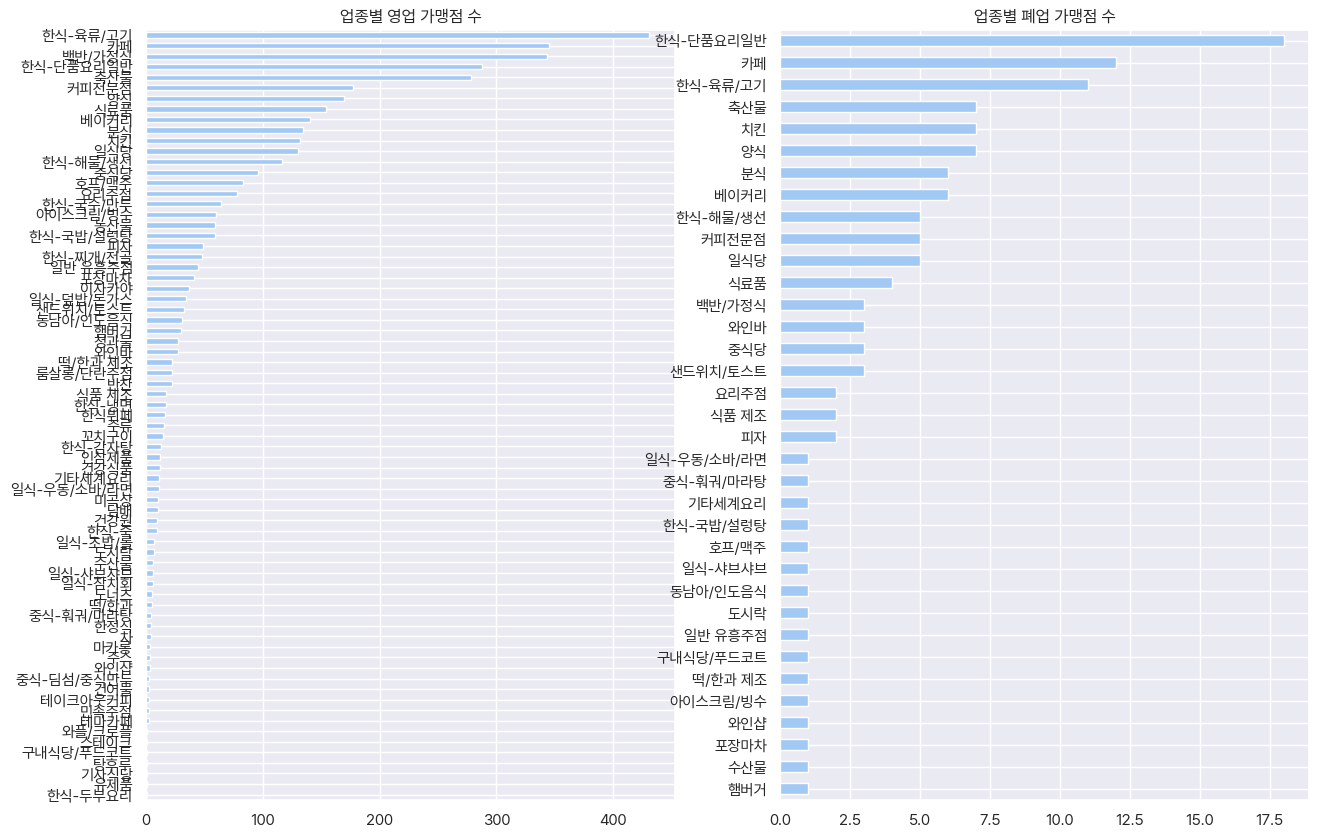

In [59]:
# 업종멸 영업/폐업 가맹점 수
plt.figure(figsize=(15, 10))

plt.subplot(1, 2, 1)
open_me = merchant_df.loc[merchant_df['close_date'].isna(), 'industry_name'].value_counts(ascending=True)
open_me.plot.barh()
plt.title('업종별 영업 가맹점 수')
plt.ylabel('')

closure_me = merchant_df.loc[merchant_df['close_date'].notna(), 'industry_name'].value_counts(ascending=True)
# closure_me.loc[closure_me >= 3] # 폐업 업종이 3 이상인 경우만 표현 시
plt.subplot(1, 2, 2)
closure_me.plot.barh()
plt.title('업종별 폐업 가맹점 수')
plt.ylabel('')

plt.show()

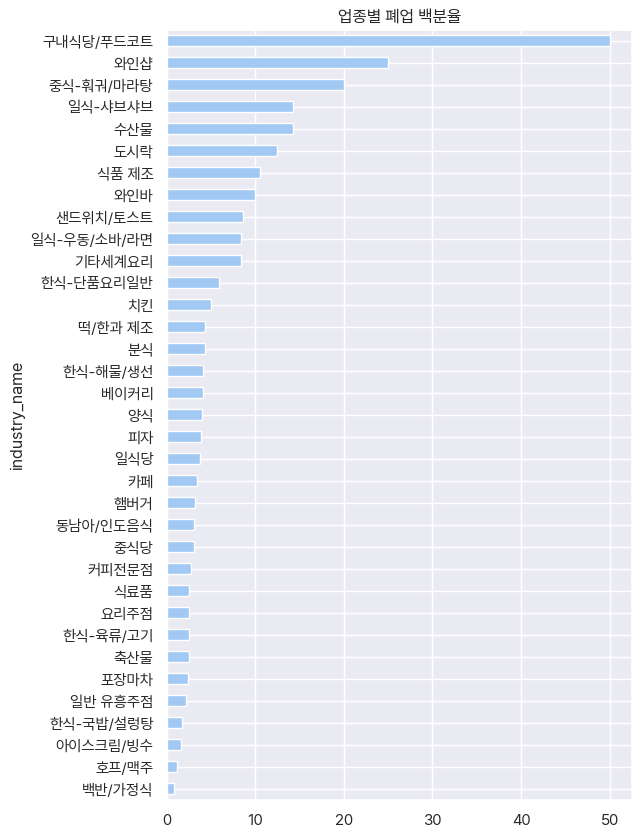

In [60]:
# 업종별 폐업 백분율
total = merchant_df['industry_name'].value_counts() # 전체 업종별 수
closed = merchant_df.loc[merchant_df['close_date'].notna(), 'industry_name'].value_counts().reindex(total.index, fill_value=0) # 인덱스 맞추기
plt.figure(figsize=(6, 10))
((closed / total)[(closed / total) > 0]*100).sort_values().plot.barh()
plt.title('업종별 폐업 백분율')
plt.show()

### 상권

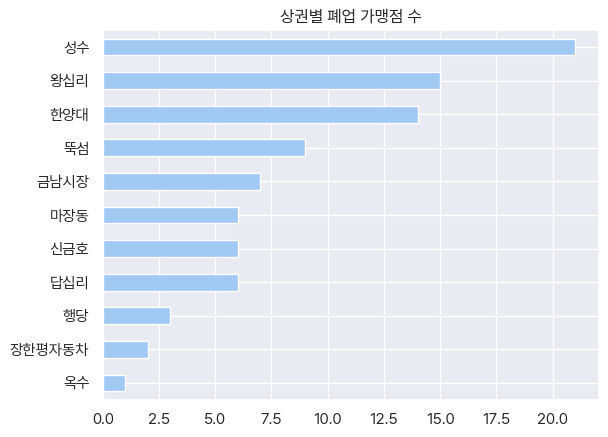

In [61]:
# 상권별 폐업 가맹점 수
merchant_df.loc[merchant_df['close_date'].notna(), 'commercial_area'].value_counts(ascending=True).plot.barh()
plt.title('상권별 폐업 가맹점 수')
plt.ylabel('')
plt.show()

Text(0.5, 1.0, '상권별 폐업 가맹점 백분율')

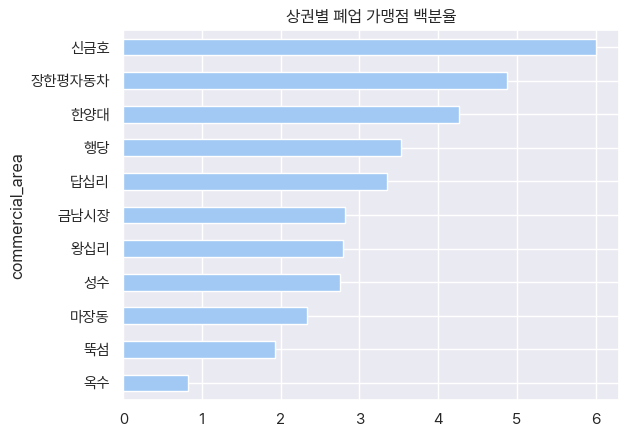

In [62]:
# 상권별 폐업 가맹점 백분율
total = merchant_df['commercial_area'].value_counts()
closed = merchant_df.loc[merchant_df['close_date'].notna(), 'commercial_area'].value_counts().reindex(total.index, fill_value=0)
((closed / total)[(closed / total)>0] * 100).sort_values().plot.barh()
plt.title('상권별 폐업 가맹점 백분율')

### 주소

In [63]:
#  주소의 동/로 정보 나타내는 컬럼 추가한 데이터프레임
merchant_ro = merchant_df.copy()
merchant_ro['dong_ro'] = merchant_ro['mct_address'].str.split(expand=True)[2]

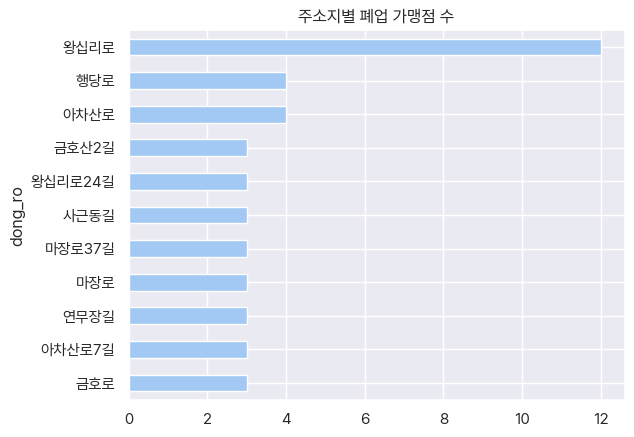

In [64]:
dong_ro = merchant_ro.loc[merchant_ro['close_date'].notna(), 'dong_ro'].value_counts(ascending=True)
dong_ro[dong_ro>=3].plot.barh()
plt.title('주소지별 폐업 가맹점 수')
plt.show()

- 상권은 성수가 많은데, 주소지는 왜 성수가 안보이지?

In [65]:
merchant_ro[(merchant_ro['close_date'].notna()) & (merchant_ro['commercial_area']=='성수')]

,mct_id,mct_address,mct_name,brand_code,sigungu,industry_name,commercial_area,open_date,close_date,dong_ro
232,2889D57BC9,서울 성동구 성수동2가,영남***,NaN,서울 성동구,식품 제조,성수,20111214,20250731.0,성수동2가
525,AD57E72BC9,서울 성동구 아차산로 92.,하루*******************,NaN,서울 성동구,카페,성수,20161012,20250801.0,아차산로
907,81E3DAF03B,서울 성동구 성수이로 32-7.,크래*****,NaN,서울 성동구,한식-단품요리일반,성수,20160805,20250811.0,성수이로
1932,C8BFE622A5,서울특별시 성동구 성덕정길 78,앵무****,NaN,서울 성동구,구내식당/푸드코트,성수,20230927,20250721.0,성덕정길
1963,C1FA7755FC,서울특별시 성동구 성수이로 90,사람************,백반/가정식12,서울 성동구,백반/가정식,성수,20190529,20250729.0,성수이로
1998,202266AAE4,서울특별시 성동구 아차산로 84,쿠키*,NaN,서울 성동구,한식-단품요리일반,성수,20220421,20250728.0,아차산로
2005,CB17914E57,서울특별시 성동구 아차산로 96,규카******,NaN,서울 성동구,일식당,성수,20230821,20250716.0,아차산로
2202,F200A12359,서울특별시 성동구 광나루로 233,신가*,NaN,서울 성동구,한식-단품요리일반,성수,20230802,20250821.0,광나루로
2543,E476C4A851,서울특별시 성동구 아차산로 126,마르***,NaN,서울 성동구,한식-단품요리일반,성수,20210521,20240102.0,아차산로
2796,8CF39A31E0,서울특별시 성동구 뚝섬로 385-32,밀단*,NaN,서울 성동구,일식-샤브샤브,성수,20171016,20250808.0,뚝섬로


In [66]:
merchant_df['commercial_area'].unique()

array(['마장동', nan, '한양대', '장한평자동차', '답십리', '왕십리', '행당', '뚝섬', '옥수', '신금호',
       '금남시장', '성수', '서면역', '건대입구', '동대문역사문화공원역', '압구정로데오', '오남', '화양시장',
       '방배역', '미아사거리', '풍산지구', '자양'], dtype=object)

In [67]:
merchant_ro[merchant_ro['commercial_area']=='행당']

,mct_id,mct_address,mct_name,brand_code,sigungu,industry_name,commercial_area,open_date,close_date,dong_ro
13,C3E6D8B14F,서울 성동구 행당동,이혜*******,NaN,서울 성동구,인삼제품,행당,20131216,NaN,행당동
50,21752D89FB,서울 성동구 행당동,영*,NaN,서울 성동구,건강식품,행당,20090316,NaN,행당동
51,80E637212D,서울 성동구 행당동,에스******,NaN,서울 성동구,커피전문점,행당,20110808,NaN,행당동
52,CEF3D93273,서울 성동구 행당동,종로**,NaN,서울 성동구,떡/한과 제조,행당,20061026,NaN,행당동
53,33361C935B,서울 성동구 행당동,만두**,NaN,서울 성동구,한식-국수/만두,행당,20101112,NaN,행당동
70,55B4F11C0E,서울 성동구 행당2동,김밥**,NaN,서울 성동구,분식,행당,20101011,NaN,행당2동
71,C75AC23756,서울 성동구 행당2동,대림****,NaN,서울 성동구,축산물,행당,20000627,NaN,행당2동
115,A4369EE806,서울 성동구 행당로 79,비타***,NaN,서울 성동구,반찬,행당,20151112,NaN,행당로
208,BD1FD7F407,서울 성동구 행당로 103,바르********,분식10,서울 성동구,분식,행당,20141204,NaN,행당로
209,9977D38E3F,서울 성동구 행당로 119,이삭***,샌드위치/토스트3,서울 성동구,샌드위치/토스트,행당,20150430,NaN,행당로


In [97]:
from geopy.geocoders import Nominatim
import pandas as pd

geolocator = Nominatim(user_agent="geo_test", timeout=10)
merchant_ro_s = merchant_ro[merchant_ro['commercial_area']=='신금호']
# 주소를 좌표로 변환
merchant_ro_s["coords"] = merchant_ro_s["mct_address"].apply(lambda x: geolocator.geocode(x))
merchant_ro_s["latitude"] = merchant_ro_s["coords"].apply(lambda x: x.latitude if x else None)
merchant_ro_s["longitude"] = merchant_ro_s["coords"].apply(lambda x: x.longitude if x else None)

In [98]:
import folium

# 서울 중심 좌표 기준 지도 생성
m = folium.Map(location=[37.5665, 126.9780], zoom_start=12)

# 데이터프레임의 좌표를 지도에 마커로 표시
for i, row in merchant_ro_s.dropna(subset=["latitude", "longitude"]).iterrows():
    folium.Marker(
        location=[row["latitude"], row["longitude"]],
        popup=row["mct_address"],
    ).add_to(m)

m.save("../visualization/신금호.html")  # HTML 파일로 저장해서 브라우저에서 확인 가능

In [30]:
merchant_df.loc[merchant_df['mct_address'] == '서울특별시 성동구 고산자로 339-2']

,mct_id,mct_address,mct_name,brand_code,sigungu,industry_name,commercial_area,open_date,close_date
3125,CDAEDB0A25,서울특별시 성동구 고산자로 339-2,이디********,커피전문점6,서울 성동구,커피전문점,마장동,20190220,NaN


<Axes: >

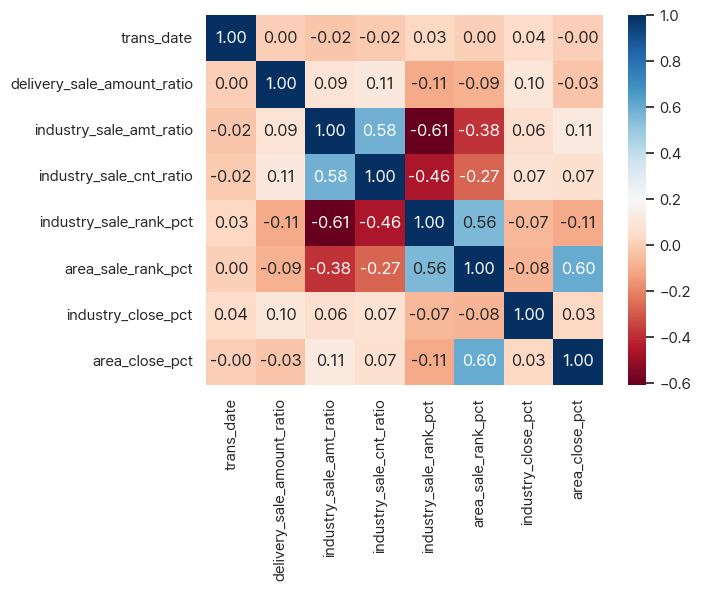

In [31]:
sns.heatmap(sale_df.select_dtypes(exclude='object').corr(), annot=True, fmt='.2f', cmap='RdBu')

# Feature Engineering

### Merge DataFrame (시각화 전용)

In [32]:
# 각 프랜차이즈가 기준이 아닌, 월별 데이터를 기준으로 merge 하는 경우
merged_df = merchant_df.merge(sale_df, on='mct_id').merge(cust_df, on=['mct_id', 'trans_date'])

In [33]:
# 영업 가맹점 매출금액 구간 빈도
merged_df.loc[merged_df['close_date'].isna(), 'sale_amt_band'].value_counts()

sale_amt_band
3_25-50%              21302
4_50-75%              21139
2_10-25%              12784
5_75-90%              12564
1_10%이하                8538
6_90%초과(하위 10% 이하)     7929
Name: count, dtype: int64

In [34]:
# 폐업 가맹점 매출금액 구간 빈도
merged_df.loc[merged_df['close_date'].notna(), 'sale_amt_band'].value_counts()

sale_amt_band
4_50-75%              553
3_25-50%              498
2_10-25%              383
5_75-90%              348
6_90%초과(하위 10% 이하)    291
1_10%이하               261
Name: count, dtype: int64

In [35]:
# 날짜 데이터 datetime으로 type변경 / 폐업일자 결측치 2026년 1월 1일로 대체
merged_df['open_date'] = pd.to_datetime(merged_df['open_date'], format='%Y%m%d')
merged_df['close_date'] = pd.to_datetime(merged_df['close_date'], format='%Y%m%d').fillna('2026-01-01') # 영업중인 가게 폐업일 2026-01-01로 대체
merged_df['trans_date'] = pd.to_datetime(merged_df['trans_date'], format='%Y%m')

In [36]:
# closed_ = merged_df.loc[merged_df['close_date'].dt.year != 2026, 'mct_id'].unique().tolist()
# open_id = merged_df.loc[merged_df['close_date'].dt.year == 2026, 'mct_id'].unique().tolist()

In [37]:
# # 폐업 가맹점
# merged_df.loc[(merged_df['close_date'].dt.year != 2026) & (merged_df['mct_id'] == closed_id[0])].sort_values('TA_YM', ascending=False)

In [38]:
# # 영업중인 가맹점
# merged_df.loc[(merged_df['close_date'].dt.year == 2026) & (merged_df['mct_id'] == open_id[3])].sort_values('TA_YM', ascending=False)

In [39]:
merged_df[merged_df['commercial_area'] == '장한평자동차']

,mct_id,mct_address,mct_name,brand_code,sigungu,industry_name,commercial_area,open_date,close_date,trans_date,operation_band,sale_amt_band,sale_cnt_band,unique_customer_band,aov_band,cancel_rate_band,delivery_sale_amount_ratio,industry_sale_amt_ratio,industry_sale_cnt_ratio,industry_sale_rank_pct,area_sale_rank_pct,industry_close_pct,area_close_pct,male_u20,male_u30,male_u40,male_u50,male_u60,female_u20,female_u30,female_u40,female_u50,female_u60,visit_re,visit_new,route_resident,route_worker,route_floating
240,BAACCE3A2C,서울 성동구 용답동,좋은**,NaN,서울 성동구,식료품,장한평자동차,2013-03-05,2026-01-01,2024-02-01,2_10-25%,4_50-75%,3_25-50%,3_25-50%,5_75-90%,1_상위1구간,-999999.9,28.9,74.8,24.9,29.9,13.2,6.8,0.1960,3.2144,7.4480,10.1528,18.1888,0.3040,4.9856,11.5520,15.7472,28.2112,26.61,7.34,0.0,1.6,98.4
241,BAACCE3A2C,서울 성동구 용답동,좋은**,NaN,서울 성동구,식료품,장한평자동차,2013-03-05,2026-01-01,2024-09-01,2_10-25%,5_75-90%,4_50-75%,4_50-75%,5_75-90%,1_상위1구간,-999999.9,14.3,26.0,27.3,32.3,12.4,7.1,0.5404,3.7056,6.6006,8.9166,18.7982,0.8596,5.8944,10.4994,14.1834,29.9018,26.72,4.38,0.0,0.0,100.0
242,BAACCE3A2C,서울 성동구 용답동,좋은**,NaN,서울 성동구,식료품,장한평자동차,2013-03-05,2026-01-01,2023-08-01,2_10-25%,5_75-90%,3_25-50%,3_25-50%,5_75-90%,1_상위1구간,-999999.9,19.7,58.5,35.0,32.4,12.0,6.7,1.1484,4.3956,7.6032,9.5436,16.9488,1.7516,6.7044,11.5968,14.5564,25.8512,23.06,6.71,0.0,1.7,98.3
243,BAACCE3A2C,서울 성동구 용답동,좋은**,NaN,서울 성동구,식료품,장한평자동차,2013-03-05,2026-01-01,2023-12-01,2_10-25%,5_75-90%,4_50-75%,4_50-75%,5_75-90%,1_상위1구간,-999999.9,13.6,36.5,25.5,31.7,13.3,5.8,0.1604,3.2080,7.1378,10.7869,18.8069,0.2396,4.7920,10.6622,16.1131,28.0931,26.68,2.80,0.0,0.0,100.0
244,BAACCE3A2C,서울 성동구 용답동,좋은**,NaN,서울 성동구,식료품,장한평자동차,2013-03-05,2026-01-01,2024-01-01,2_10-25%,5_75-90%,4_50-75%,4_50-75%,5_75-90%,1_상위1구간,-999999.9,23.1,57.0,25.5,31.6,13.4,6.3,0.2358,3.1440,7.3884,10.1394,18.3924,0.3642,4.8560,11.4116,15.6606,28.4076,27.46,4.36,0.0,0.0,100.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83633,41FCF57F43,서울특별시 성동구 자동차시장1길 85,그레*****,NaN,서울 성동구,카페,장한평자동차,2023-10-18,2026-01-01,2024-11-01,5_75-90%,5_75-90%,4_50-75%,4_50-75%,5_75-90%,5_상위5구간,30.9,21.1,21.1,57.8,38.2,14.0,7.0,4.2529,12.4592,14.1963,15.0948,13.8369,2.8471,8.3408,9.5037,10.1052,9.2631,41.58,6.44,7.4,29.6,63.0
83634,41FCF57F43,서울특별시 성동구 자동차시장1길 85,그레*****,NaN,서울 성동구,카페,장한평자동차,2023-10-18,2026-01-01,2023-11-01,6_90%초과(하위 10% 이하),5_75-90%,4_50-75%,4_50-75%,5_75-90%,5_상위5구간,24.0,23.8,28.6,83.9,61.9,14.1,5.6,6.0770,16.6860,6.0770,10.6090,12.1025,5.7230,15.7140,5.7230,9.9910,11.3975,27.78,77.78,0.0,39.3,60.7
83635,41FCF57F43,서울특별시 성동구 자동차시장1길 85,그레*****,NaN,서울 성동구,카페,장한평자동차,2023-10-18,2026-01-01,2024-12-01,5_75-90%,5_75-90%,4_50-75%,4_50-75%,5_75-90%,1_상위1구간,25.7,28.1,34.7,54.0,38.7,18.0,6.7,4.2490,12.3828,14.0217,15.2964,14.7501,2.7510,8.0172,9.0783,9.9036,9.5499,40.78,8.74,7.7,23.1,69.2
83636,41FCF57F43,서울특별시 성동구 자동차시장1길 85,그레*****,NaN,서울 성동구,카페,장한평자동차,2023-10-18,2026-01-01,2024-04-01,6_90%초과(하위 10% 이하),5_75-90%,3_25-50%,4_50-75%,5_75-90%,1_상위1구간,3.0,24.1,27.0,68.1,47.8,14.4,6.3,5.2635,15.1855,12.8865,13.5520,13.5520,3.4365,9.9145,8.4135,8.8480,8.8480,38.06,13.43,3.1,40.6,56.3


In [40]:
merchant_df['commercial_area'].value_counts()

commercial_area
성수            762
왕십리           538
뚝섬            468
한양대           328
마장동           257
금남시장          249
답십리           179
옥수            121
신금호           100
행당             85
장한평자동차         41
서면역             1
건대입구            1
동대문역사문화공원역      1
압구정로데오          1
오남              1
화양시장            1
방배역             1
미아사거리           1
풍산지구            1
자양              1
Name: count, dtype: int64

In [41]:
band_cols = merged_df.loc[:, 'operation_band':'cancel_rate_band'].columns
merged_df.loc[: ,band_cols] = merged_df.loc[:, band_cols].apply(lambda x: x.str.split('_', expand=True)[0])
merged_df[band_cols] = merged_df[band_cols].fillna(1).astype(int)

In [42]:
# 결측치는 0으로
merged_df['delivery_sale_amount_ratio'] = merged_df['delivery_sale_amount_ratio'].apply(lambda x: 0 if x < 0 else x)
merged_df['area_close_pct'] = merged_df['area_close_pct'].map(lambda x: 0 if x < 0 else x)

In [43]:
# 폐업 매장 중 매출건수 3구간 이내인 데이터
merged_df.loc[(merged_df['close_date'].dt.year != 2026) & (merged_df['sale_cnt_band'] < 4)].sort_values('close_date')

,mct_id,mct_address,mct_name,brand_code,sigungu,industry_name,commercial_area,open_date,close_date,trans_date,operation_band,sale_amt_band,sale_cnt_band,unique_customer_band,aov_band,cancel_rate_band,delivery_sale_amount_ratio,industry_sale_amt_ratio,industry_sale_cnt_ratio,industry_sale_rank_pct,area_sale_rank_pct,industry_close_pct,area_close_pct,male_u20,male_u30,male_u40,male_u50,male_u60,female_u20,female_u30,female_u40,female_u50,female_u60,visit_re,visit_new,route_resident,route_worker,route_floating
15870,7E27181707,서울 성동구 마조로9길 6-3,뺑드*,NaN,서울 성동구,베이커리,한양대,2016-07-04,2023-01-05,2023-01-01,6,4,3,3,5,1,0.0,26.6,40.3,9.7,16.7,12.6,10.0,16.6470,5.8280,3.6580,3.8440,1.0230,37.0530,12.9720,8.1420,8.5560,2.2770,39.61,0.78,44.2,8.1,47.7
85028,FE30B6645E,서울특별시 성동구 왕십리로24길 27-1,후라**************,치킨40,서울 성동구,치킨,왕십리,2019-01-24,2023-03-21,2023-01-01,4,3,3,3,4,1,75.7,106.5,201.4,14.9,24.4,14.8,8.9,18.5504,14.0492,10.9802,15.4814,9.0706,8.6496,6.5508,5.1198,7.2186,4.2294,34.02,4.57,65.8,7.0,27.2
85029,FE30B6645E,서울특별시 성동구 왕십리로24길 27-1,후라**************,치킨40,서울 성동구,치킨,왕십리,2019-01-24,2023-03-21,2023-03-01,6,4,3,3,4,4,78.5,75.6,148.8,15.4,24.5,15.9,9.4,18.4764,14.8780,10.9336,15.4316,9.4804,8.2236,6.6220,4.8664,6.8684,4.2196,35.34,4.81,67.0,7.3,25.7
85027,FE30B6645E,서울특별시 성동구 왕십리로24길 27-1,후라**************,치킨40,서울 성동구,치킨,왕십리,2019-01-24,2023-03-21,2023-02-01,4,3,2,2,4,1,74.1,121.9,226.3,14.9,24.1,15.5,9.1,18.6300,14.2830,11.1090,15.3180,9.5910,8.3700,6.4170,4.9910,6.8820,4.3090,35.26,6.20,63.1,6.2,30.8
64875,8D7C69A199,서울특별시 성동구 연무장7길 8-1,커피**********,NaN,서울 성동구,커피전문점,성수,2019-10-28,2023-04-18,2023-03-01,4,4,3,3,5,5,0.0,31.9,51.3,49.8,44.7,11.1,8.6,21.7616,13.7886,6.4253,3.2830,1.6415,24.6384,15.6114,7.2747,3.7170,1.8585,19.81,9.90,14.9,24.8,60.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66315,999B6B5297,서울특별시 성동구 고산자로2길 65,할머************,NaN,서울 성동구,분식,NaN,2024-01-04,2025-08-22,2024-10-01,5,4,3,3,4,6,61.4,74.1,67.2,30.9,0.0,15.5,0.0,2.5707,11.9064,15.7399,10.1475,4.7806,3.1293,14.4936,19.1601,12.3525,5.8194,36.59,6.51,74.5,5.9,19.6
66316,999B6B5297,서울특별시 성동구 고산자로2길 65,할머************,NaN,서울 성동구,분식,NaN,2024-01-04,2025-08-22,2024-04-01,6,4,3,3,4,4,47.8,101.8,102.9,48.7,0.0,16.1,0.0,2.8207,10.9460,14.7350,9.2199,4.4205,3.8793,15.0540,20.2650,12.6801,6.0795,35.22,16.94,77.0,2.3,20.7
66317,999B6B5297,서울특별시 성동구 고산자로2길 65,할머************,NaN,서울 성동구,분식,NaN,2024-01-04,2025-08-22,2024-02-01,6,4,3,3,5,5,44.8,123.2,148.9,63.1,0.0,16.4,0.0,2.1060,11.5830,14.8635,7.6950,4.2525,3.0940,17.0170,21.8365,11.3050,6.2475,33.51,43.24,81.9,1.9,16.2
66319,999B6B5297,서울특별시 성동구 고산자로2길 65,할머************,NaN,서울 성동구,분식,NaN,2024-01-04,2025-08-22,2024-01-01,6,4,3,3,4,6,13.0,115.1,131.7,74.6,0.0,16.6,0.0,3.3540,11.1540,14.1180,7.4100,2.9640,5.2460,17.4460,22.0820,11.5900,4.6360,25.71,100.00,88.6,2.9,8.6


In [44]:
# 브랜드 여부
# 폐업 127개 중, 111개 브랜드 아님, 16개 브랜드

In [45]:
# 매출이 높던 가게는 왜 폐업을 했을까
# merged_df.loc[merged_df['mct_id']=='1F369B9364'].sort_values('trans_date')

In [50]:
# 매출금액 구간 6인 경우
# merged_df.loc[merged_df['sale_amt_band'] > 5].sort_values('mct_id').head(10)

- 상권, 임대료, 마진율, 물가상승, 비슷한 업종 경쟁 심화

In [67]:
# 업종별 매출 데이터
merged_df.groupby('industry_name')[['sale_amt_band', 'sale_cnt_band']].mean().sort_values('sale_cnt_band')

,sale_amt_band,sale_cnt_band
industry_name,,
차,2.187500,1.020833
기사식당,1.541667,1.750000
커피전문점,3.240448,1.872817
주스,3.563636,1.981818
아이스크림/빙수,3.583935,2.079422
일식-샤브샤브,1.635593,2.186441
민속주점,2.259259,2.259259
햄버거,2.805556,2.343137
한식-두부요리,2.250000,2.416667


In [ ]:
# 상권별 매출 데이터
merged_df.groupby('commercial_area')[['sale_amt_band', 'sale_cnt_band']].mean().sort_values('sale_cnt_band')

,sale_amt_band,sale_cnt_band
commercial_area,,
서면역,2.166667,1.375000
한양대,2.782552,2.754005
건대입구,3.416667,3.000000
뚝섬,3.131437,3.055495
성수,3.167821,3.202505
행당,3.774878,3.202828
신금호,3.602786,3.320365
옥수,3.388194,3.460125
답십리,3.561145,3.505559


In [64]:
# merged_df.loc[(merged_df['close_date'].dt.year != 2026)].sort_values('close_date').head(100)

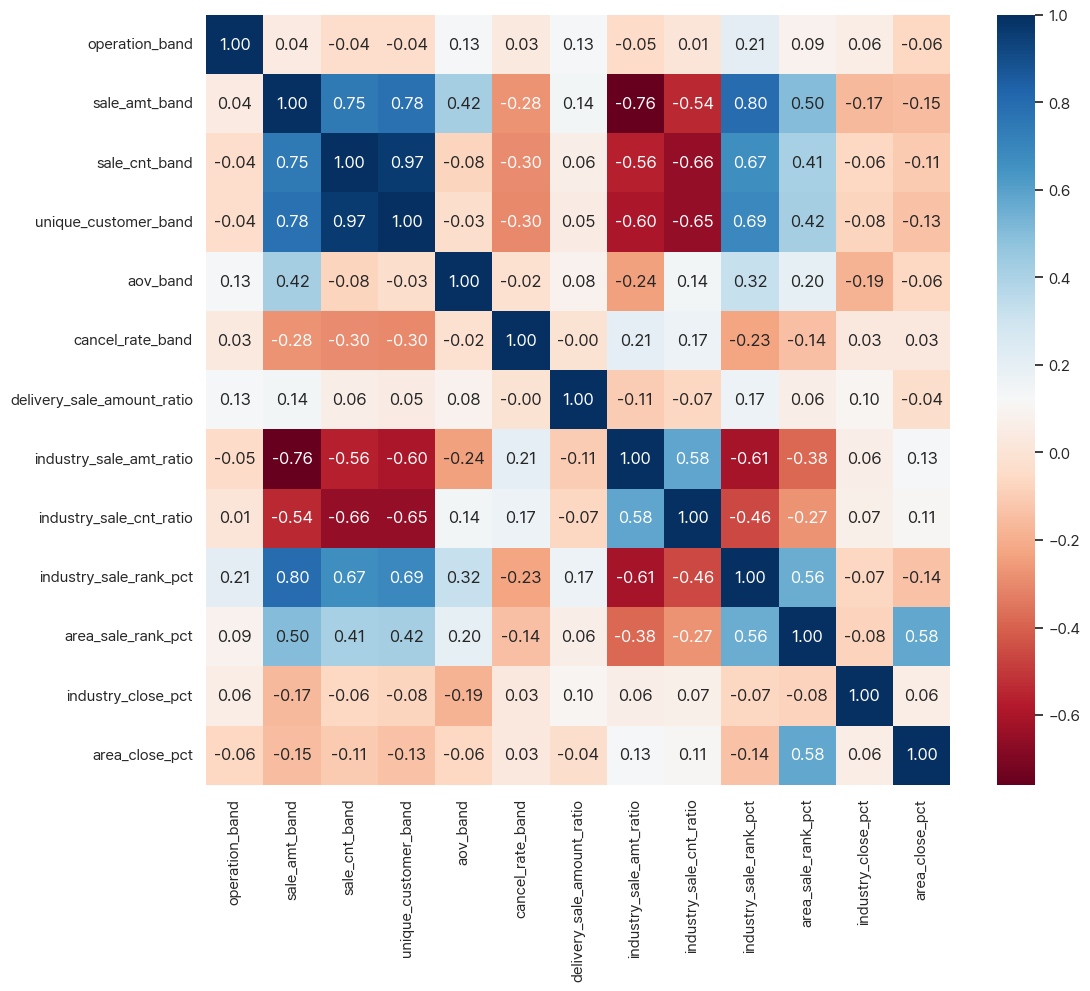

In [47]:
plt.figure(figsize=(12, 10))
sns.heatmap(merged_df.iloc[:, 10:23].corr(), cmap='RdBu', fmt='.2f', annot=True)
plt.show()

### 상관계수
- sale_cnt_band와 unique_customer_band => 0.97 => cnt 있으면 unique 제외 가능
- sale_amt_band와 industry_sale_rank_pct => 0.8 
- sale_amt_band와 unique_customer_band => 0.78
- sale_amt_band와 sale_cnt_band => 0.75
등등

### 가맹점 개요 정보
- **mct_id**: 가맹점 구분번호 => 제거
- **mct_address**: 가맹점주소 => 제거
- **mct_name**: 가맹점명 (앞 2글자 이후 마스킹처리, 2글자면 앞 1자리만, 1글자면 전부 마스킹) => 제거
- **brand_code**: 브랜드구분코드 (동일 브랜드 매장 식별 위한 구분 코드) => 동일한 브랜드 나타냄 ex) 비비큐는 치킨2 => 제거
- **sigungu**: 가맹점지역 => 제거
- **industry_name**: 업종 => 원핫인코딩
- **commercial_area**: 상권 => 원핫인코딩
- **open_date**: 개설일 => 제거
- **close_date**: 폐업일 => 제거

### 가맹점 월별 이용 정보
- **mct_id**: 가맹점구분번호 
- **TA_YM**: 기준년월 
- **MCT_OPE_MS_CN**: 가맹점 운영개월수 구간 => 가장 최신걸로 반영
- **RC_M1_SAA**: 매출금액 구간 => 최근 1년간의 평균
- **RC_M1_TO_UE_CT**: 매출건수 구간 => 최근 1년간의 평균
- **RC_M1_UE_CUS_CN**: 유니크 고객 수 구간 => 최근 1년간의 평균
- **RC_M1_AV_NP_AT**: 객단가 구간 => 매출/고객 수 데이터와 다중공선성 우려 => 제거
- **APV_CE_RAT**: 취소율 구간 => 최근 1년간의 평균
- **DLV_SAA_RAT**: 배달매출금액 비율 ( 배달매출 미존재시 SV (-999999.9) ) => 최근 1년간의 평균
- **M1_SME_RY_SAA_RAT**: 동일 업종 매출금액 비율 => 최근 1년간의 평균
- **M1_SME_RY_CNT_RAT**: 동일 업종 매출건수 비율 => 최근 1년간의 평균
- **M12_SME_RY_SAA_PCE_RT**: 동일 업종 내 매출 순위 비율 => 최근 1년간의 평균
- **M12_SME_BZN_SAA_PCE_RT**: 동일 상권 내 매출 순위 비율 => 최근 1년간의 평균
- **M12_SME_RY_ME_MCT_RAT**: 동일 업종 내 해지 가맹점 비중 => 최근 1년간의 평균
- **M12_SME_BZN_ME_MCT_RAT**: 동일 상권 내 해지 가맹점 비중 ( 상권 미존재시 SV (-999999.9) )   => 최근 1년간의 평균
참고) 객단가: 고객 1인당 평균 매입액 (총매출/고객수)

### 가맹점 월별 이용 고객정보
- **mct_id**: 가맹점구분번호
- **trans_date**: 기준년월
    - 아래 컬럼 모두 고객 정보 미존재시 SV (-999999.9)
- **male_u20**: 남성 20대이하 고객 비중
- **male_u30**: 남성 30대이하 고객 비중
- **male_u40**: 남성 40대이하 고객 비중
- **male_u50**: 남성 50대이하 고객 비중
- **male_u60**: 남성 60대이하 고객 비중
- **female_u20**: 여성 20대이하 고객 비중
- **female_u30**: 여성 30대이하 고객 비중
- **female_u40**: 여성 40대이하 고객 비중
- **female_u50**: 여성 50대이하 고객 비중
- **female_u60**: 여성 60대이하 고객 비중
- **visit_re**: 재방문 고객 비중
- **visit_new**: 신규 고객 비중
- **route_resident**: 거주 이용 고객 비율
- **route_worker**: 직장 이용 고객 비율
- **route_floating**: 유동인구 이용 고객 비율

########################## 여기서부터 분석 #############################

In [4]:
import os
import sys
sys.path.append(os.path.dirname(os.getcwd()))

In [5]:
sys.path

['c:\\Users\\cyj1226\\anaconda3\\envs\\myenv\\python310.zip',
 'c:\\Users\\cyj1226\\anaconda3\\envs\\myenv\\DLLs',
 'c:\\Users\\cyj1226\\anaconda3\\envs\\myenv\\lib',
 'c:\\Users\\cyj1226\\anaconda3\\envs\\myenv',
 '',
 'c:\\Users\\cyj1226\\anaconda3\\envs\\myenv\\lib\\site-packages',
 'c:\\Users\\cyj1226\\anaconda3\\envs\\myenv\\lib\\site-packages\\win32',
 'c:\\Users\\cyj1226\\anaconda3\\envs\\myenv\\lib\\site-packages\\win32\\lib',
 'c:\\Users\\cyj1226\\anaconda3\\envs\\myenv\\lib\\site-packages\\Pythonwin',
 'c:\\Users\\cyj1226\\modu\\personal\\BigContest']

In [6]:
from scripts import rename_column, preprocess_sale, preprocess_cust, preprocess_merchant

In [7]:
merchant_df, sale_df, cust_df = rename_column(merchant_df, sale_df, cust_df)

In [8]:
# cust_df 수치화
# 결측치는 0으로 대체
cust_cols = cust_df.iloc[:, 2:].columns
cust_df[cust_cols] = cust_df[cust_cols].clip(lower=0)

#  100 - (첫방문 비율 + 재방문 비율) 나타내는 컬럼 추가
cust_df['visit_unknown'] = 100 - (cust_df['visit_re'] + cust_df['visit_new'])

# visit 관련 컬럼끼리 보기 편하게 컬럼 순서 조정
cust_df = cust_df[['mct_id', 'trans_date', 'male_u20', 'male_u30', 'male_u40', 'male_u50', 'male_u60', 'female_u20', 'female_u30', 'female_u40',
                       'female_u50', 'female_u60', 'visit_re', 'visit_new', 'visit_unknown', 'route_resident', 'route_worker', 'route_floating']]

In [9]:
# 구간 데이터 앞에 숫자만 빼오기
sale_df.loc[:, 'operation_band':'cancel_rate_band'] = sale_df.loc[:, 'operation_band':'cancel_rate_band'].apply(lambda x: x.str.split('_', expand=True)[0])

# 결측치 최빈값으로 대체 후 구간 데이터들의 자료형 int형으로 변환
# 가정: 결측값의 경우 취소율이 적다고 판단!!
band_cols = sale_df.loc[:, 'operation_band':'cancel_rate_band'].columns
sale_df[band_cols] = sale_df[band_cols].fillna(1).astype(int)

## 비율 데이터 전처리
# 배달매출금액 비율의 -999999.9는 배달매출 미존재 의미 => 0으로 대체 가능 (배달매출금액 비율이 처음부터 0인 데이터도 있긴 함)
sale_df['delivery_sale_amount_ratio'] = sale_df['delivery_sale_amount_ratio'].map(lambda x: 0 if x < 0 else x)

# 동일 상권 내 해지 가맹점 비중의 -999999.9는 상권 미존재 의미 => 100으로 할 수 도 있겠으나 일단 0으로 대체
sale_df['area_close_pct'] = sale_df['area_close_pct'].map(lambda x: 0 if x < 0 else x)

In [10]:
## 업종 그룹화 
meat = ['한식-육류/고기',  '꼬치구이']
cafe = ['카페',  '주스',  '차',  '테마카페',  '커피전문점', '테이크아웃커피',  '구내식당/푸드코트']
k_food = ['백반/가정식',  '기사식당', '한식-두부요리', '한식-단품요리일반',  '한정식',    '한식-죽',  '한식-국수/만두',  '한식-국밥/설렁탕',  '한식-찌개/전골',  '한식-냉면',  '한식뷔페',  '한식-감자탕',   '한식-해물/생선']
w_food = ['양식',  '스테이크', '치킨',  '햄버거',  '피자']
j_food = ['일식당',  '일식-우동/소바/라면',  '일식-초밥/롤',  '일식-덮밥/돈가스',  '일식-샤브샤브',  '일식-참치회']
c_food = ['중식당',  '중식-딤섬/중식만두',  '중식-훠궈/마라탕']
drink = ['호프/맥주',  '요리주점',  '민속주점',  '포장마차',  '이자카야',  '와인바', '주류',  '와인샵']
product= ['농산물',  '청과물',  '수산물',  '건어물',  '축산물']
enter = ['일반 유흥주점',  '룸살롱/단란주점']
convenience = ['샌드위치/토스트',  '도시락', '분식']
world_food = ['동남아/인도음식',  '기타세계요리']
dessert = ['도너츠',  '탕후루',  '와플/크로플',  '마카롱',  '아이스크림/빙수',  '떡/한과',  '떡/한과 제조',  '베이커리']
others = ['식품 제조',  '반찬',  '미곡상',  '유제품',  '인삼제품', '건강식품', '건강원', '담배',  '식료품']

# replace 진행
groups_to_replace = [(meat, 'meat'), (cafe, 'cafe'), (k_food, 'k_food'), (w_food, 'w_food'), (j_food, 'j_food'),
                        (c_food, 'c_food'), (drink, 'drink'), (product, 'product'), (enter, 'enter'), (convenience, 'convenience'),
                        (world_food, 'world_food'), (dessert, 'dessert'), (others, 'others')]

replacement = {}
for ind, cat in groups_to_replace:
    for i in ind:
        replacement[i] = cat

merchant_df['industry_name'].replace(replacement, inplace=True)

## 상권 그룹화
# 상권 데이터 1개만 존재하는 경우 주변 상권과 통합 (장한평자동차와 답십리는 모두 구석진 곳인데 가까우므로 결합)
areas_to_replace = {'화양시장': '성수', '자양': '성수', '서면역': '성수', '미아사거리': '성수',
                    '방배역': '뚝섬', '건대입구': '뚝섬', '풍산지구': '뚝섬', '오남': '한양대',
                    '동대문역사문화공원역': '금남시장',  '압구정로데오': '금남시장',  '장한평자동차': '답십리'}

merchant_df['commercial_area'].replace(areas_to_replace, inplace=True)

# 상권 결측치는 Unknown으로 대체
merchant_df['commercial_area'].fillna('Unknown', inplace=True)

In [11]:
merged_df = merchant_df.merge(sale_df, on='mct_id').merge(cust_df, on=['mct_id', 'trans_date'])

In [12]:
merged_df

,mct_id,mct_address,mct_name,brand_code,sigungu,industry_name,commercial_area,open_date,close_date,trans_date,operation_band,sale_amt_band,sale_cnt_band,unique_customer_band,aov_band,cancel_rate_band,delivery_sale_amount_ratio,industry_sale_amt_ratio,industry_sale_cnt_ratio,industry_sale_rank_pct,area_sale_rank_pct,industry_close_pct,area_close_pct,male_u20,male_u30,male_u40,male_u50,male_u60,female_u20,female_u30,female_u40,female_u50,female_u60,visit_re,visit_new,visit_unknown,route_resident,route_worker,route_floating
0,16184E93D9,서울 성동구 마장동,성우**,NaN,서울 성동구,product,마장동,20130320,NaN,202405,2,3,4,4,2,6,0.0,70.4,33.9,27.2,20.8,12.3,5.6,4.1480,9.0440,11.0840,19.4480,24.2760,1.9520,4.2560,5.2160,9.1520,11.4240,18.82,6.47,74.71,50.0,7.1,42.9
1,16184E93D9,서울 성동구 마장동,성우**,NaN,서울 성동구,product,마장동,20130320,NaN,202304,2,4,4,4,2,6,0.0,74.6,22.9,11.5,21.3,11.3,6.0,3.9864,11.1740,9.4224,16.9120,18.9052,2.6136,7.3260,6.1776,11.0880,12.3948,16.51,5.05,78.44,25.0,6.3,68.8
2,16184E93D9,서울 성동구 마장동,성우**,NaN,서울 성동구,product,마장동,20130320,NaN,202308,2,3,4,4,2,1,0.0,85.6,22.1,11.5,20.6,12.0,5.4,3.9060,11.2140,10.6470,17.4510,19.7820,2.2940,6.5860,6.2530,10.2490,11.6180,16.98,6.60,76.42,17.6,0.0,82.4
3,16184E93D9,서울 성동구 마장동,성우**,NaN,서울 성동구,product,마장동,20130320,NaN,202402,2,3,4,4,1,1,0.0,90.5,35.8,27.8,22.2,12.3,5.0,4.7056,10.3800,10.3800,21.8672,21.8672,2.0944,4.6200,4.6200,9.7328,9.7328,16.95,9.60,73.45,15.8,5.3,78.9
4,16184E93D9,서울 성동구 마장동,성우**,NaN,서울 성동구,product,마장동,20130320,NaN,202406,2,3,4,4,1,1,0.0,81.1,27.5,26.9,21.0,12.2,5.6,3.9345,7.8690,10.8360,18.1245,23.6715,2.1655,4.3310,5.9640,9.9755,13.0285,20.96,4.79,74.25,26.7,0.0,73.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86585,58B8C943BF,서울특별시 성동구 매봉길 50,아이******,NaN,서울 성동구,dessert,Unknown,20230303,NaN,202303,6,4,2,2,5,5,0.0,57.6,178.9,60.2,0.0,10.9,0.0,7.6608,15.2768,12.1408,6.9440,2.7776,9.4392,18.8232,14.9592,8.5560,3.4224,28.46,100.00,-28.46,72.9,4.7,22.5
86586,58B8C943BF,서울특별시 성동구 매봉길 50,아이******,NaN,서울 성동구,dessert,Unknown,20230303,NaN,202404,5,4,2,2,5,1,0.0,77.1,269.8,8.1,0.0,12.9,0.0,9.7162,15.9211,13.7085,5.3872,3.3670,10.4838,17.1789,14.7915,5.8128,3.6330,49.95,5.81,44.24,67.3,2.0,30.7
86587,58B8C943BF,서울특별시 성동구 매봉길 50,아이******,NaN,서울 성동구,dessert,Unknown,20230303,NaN,202410,5,4,1,2,6,1,0.0,84.7,403.2,9.9,0.0,12.3,0.0,10.3158,16.8283,15.4216,6.2520,3.3344,9.4842,15.4717,14.1784,5.7480,3.0656,49.54,5.26,45.20,71.6,1.6,26.8
86588,58B8C943BF,서울특별시 성동구 매봉길 50,아이******,NaN,서울 성동구,dessert,Unknown,20230303,NaN,202406,5,3,1,2,5,1,0.0,88.3,294.4,8.9,0.0,12.6,0.0,10.0572,16.2690,14.2970,5.5216,3.1552,10.3428,16.7310,14.7030,5.6784,3.2448,49.81,7.09,43.10,70.5,2.9,26.7


In [ ]:
merge_sort_df = merged_df.sort_values(by=['mct_id', 'trans_date']).reset_index(drop=True)
merge_sort_df['prev_tier'] = merge_sort_df.groupby('mct_id')['sale_amt_band'].shift(1)

,mct_id,mct_address,mct_name,brand_code,sigungu,industry_name,commercial_area,open_date,close_date,trans_date,operation_band,sale_amt_band,sale_cnt_band,unique_customer_band,aov_band,cancel_rate_band,delivery_sale_amount_ratio,industry_sale_amt_ratio,industry_sale_cnt_ratio,industry_sale_rank_pct,area_sale_rank_pct,industry_close_pct,area_close_pct,male_u20,male_u30,male_u40,male_u50,male_u60,female_u20,female_u30,female_u40,female_u50,female_u60,visit_re,visit_new,visit_unknown,route_resident,route_worker,route_floating,prev_tier
0,000F03E44A,서울특별시 성동구 왕십리로4가길 9,육육**,NaN,서울 성동구,c_food,뚝섬,20220225,NaN,202301,5,6,5,5,4,1,0.0,0.5,1.1,95.3,75.1,15.8,7.9,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,100.0000,0.0000,0.00,100.00,0.00,0.0,0.0,100.0,NaN
1,000F03E44A,서울특별시 성동구 왕십리로4가길 9,육육**,NaN,서울 성동구,c_food,뚝섬,20220225,NaN,202302,5,6,6,6,6,1,0.0,0.0,0.0,95.2,75.2,16.3,8.0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,100.0000,0.0000,0.00,0.00,100.00,0.0,0.0,0.0,6.0
2,000F03E44A,서울특별시 성동구 왕십리로4가길 9,육육**,NaN,서울 성동구,c_food,뚝섬,20220225,NaN,202303,5,6,6,6,6,1,0.0,0.0,0.0,95.0,75.2,16.7,7.9,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,100.0000,0.0000,0.00,0.00,100.00,0.0,0.0,0.0,6.0
3,000F03E44A,서울특별시 성동구 왕십리로4가길 9,육육**,NaN,서울 성동구,c_food,뚝섬,20220225,NaN,202304,5,6,5,5,3,1,0.0,1.3,1.0,94.5,74.3,17.3,8.2,0.0000,36.0000,0.0000,36.0000,0.0000,0.0000,14.0000,0.0000,14.0000,0.0000,0.00,50.00,50.00,0.0,100.0,0.0,6.0
4,000F03E44A,서울특별시 성동구 왕십리로4가길 9,육육**,NaN,서울 성동구,c_food,뚝섬,20220225,NaN,202305,5,6,5,5,6,1,0.0,0.0,1.0,94.6,74.5,17.9,8.0,0.0000,47.1569,0.0000,23.5431,0.0000,0.0000,19.5431,0.0000,9.7569,0.0000,0.00,33.33,66.67,0.0,0.0,100.0,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86585,FFF0DAC445,서울 성동구 아차산로7길 10-1.,투다*,꼬치구이3,서울 성동구,meat,성수,20160704,NaN,202408,3,2,3,3,3,1,0.0,294.8,361.7,2.8,7.6,16.6,8.0,22.0955,20.0625,6.4200,3.7450,1.2305,19.2045,17.4375,5.5800,3.2550,1.0695,9.60,6.24,84.16,16.0,20.8,63.2,1.0
86586,FFF0DAC445,서울 성동구 아차산로7길 10-1.,투다*,꼬치구이3,서울 성동구,meat,성수,20160704,NaN,202409,3,1,3,2,2,5,0.0,424.3,456.2,2.7,7.3,16.9,8.3,22.1400,20.4660,6.3180,3.9420,1.1880,18.8600,17.4340,5.3820,3.3580,1.0120,9.62,8.07,82.31,21.5,16.2,62.3,2.0
86587,FFF0DAC445,서울 성동구 아차산로7길 10-1.,투다*,꼬치구이3,서울 성동구,meat,성수,20160704,NaN,202410,3,2,3,2,3,1,0.0,333.6,386.6,2.7,7.3,16.9,8.1,21.4799,20.6804,6.0762,3.8376,1.2259,18.8201,18.1196,5.3238,3.3624,1.0741,10.27,7.48,82.25,16.8,16.0,67.2,1.0
86588,FFF0DAC445,서울 성동구 아차산로7길 10-1.,투다*,꼬치구이3,서울 성동구,meat,성수,20160704,NaN,202411,3,2,3,2,2,1,0.0,355.0,407.1,2.7,7.3,16.6,8.2,21.2464,21.2464,6.2872,4.0650,1.3550,17.9536,17.9536,5.3128,3.4350,1.1450,10.28,7.96,81.76,17.9,19.5,62.6,2.0


In [20]:
# 가맹점별 이전달과 매출 구간 차이 나타내는 컬럼 추가
# 현재 - 이전 => +면 이전 달보다 매출 감소, -면 이전 달보다 매출 증가
merge_sort_df['tier_diff'] = (merge_sort_df['sale_amt_band'] - merge_sort_df['prev_tier'])

In [ ]:
# 1단계의 merge_sort_df DataFrame을 계속 사용합니다.
# merge_sort_df: (정렬된 원본 데이터 + Prev_Tier, Tier_Drop 컬럼 포함)

# 1. 2구간 이상 하락 조건을 만족하는 행의 인덱스를 추출
drop_indices = merge_sort_df[
    (merge_sort_df['prev_tier'].notna()) &
    (merge_sort_df['tier_diff'] >= 2)
].index

# 2. 하락한 현재 행과 그 이전 행의 인덱스를 리스트로 모음
# 이전 행의 인덱스 = 현재 행 인덱스 - 1
all_indices = []
for idx in drop_indices:
    # 이전 행 인덱스 (idx - 1) 추가
    all_indices.append(idx - 1)
    # 현재 행 인덱스 (idx) 추가
    all_indices.append(idx)

# 3. 인덱스 리스트를 이용해 최종 데이터프레임 추출
# .loc[]를 사용하여 순서대로 행을 추출합니다.
final_result_stacked = merge_sort_df.loc[sorted(all_indices)]

# 시각적 구분을 위해 구분선을 추가 (옵션)
final_result_stacked['Action'] = final_result_stacked.index.map(lambda x: 'Current Month (🚨 DROP)' if x in drop_indices else 'Previous Month')

print("\n--- 2. 하락한 달과 이전 달 행을 모두 출력 ---")
# print(final_result_stacked)


--- 2. 하락한 달과 이전 달 행을 모두 출력 ---
           mct_id         mct_address          mct_name brand_code sigungu  \
127    0050D68B18   서울특별시 성동구 아차산로 87  70**************        NaN  서울 성동구   
128    0050D68B18   서울특별시 성동구 아차산로 87  70**************        NaN  서울 성동구   
172    0074C4990A          서울 성동구 마장동              대용**        NaN  서울 성동구   
173    0074C4990A          서울 성동구 마장동              대용**        NaN  서울 성동구   
177    0074C4990A          서울 성동구 마장동              대용**        NaN  서울 성동구   
...           ...                 ...               ...        ...     ...   
86248  FF0B7211A6   서울 성동구 마장로39길 14.              동일**        NaN  서울 성동구   
86252  FF0B7211A6   서울 성동구 마장로39길 14.              동일**        NaN  서울 성동구   
86253  FF0B7211A6   서울 성동구 마장로39길 14.              동일**        NaN  서울 성동구   
86505  FFAC8CC0F7  서울 성동구 성수일로12길 27.            일미****        NaN  서울 성동구   
86506  FFAC8CC0F7  서울 성동구 성수일로12길 27.            일미****        NaN  서울 성동구   

      industry_name commercial

In [29]:
final_result_stacked

,mct_id,mct_address,mct_name,brand_code,sigungu,industry_name,commercial_area,open_date,close_date,trans_date,operation_band,sale_amt_band,sale_cnt_band,unique_customer_band,aov_band,cancel_rate_band,delivery_sale_amount_ratio,industry_sale_amt_ratio,industry_sale_cnt_ratio,industry_sale_rank_pct,area_sale_rank_pct,industry_close_pct,area_close_pct,male_u20,male_u30,male_u40,male_u50,male_u60,female_u20,female_u30,female_u40,female_u50,female_u60,visit_re,visit_new,visit_unknown,route_resident,route_worker,route_floating,prev_tier,tier_diff,Action
127,0050D68B18,서울특별시 성동구 아차산로 87,70**************,NaN,서울 성동구,enter,성수,20230531,NaN,202312,5,2,4,4,1,1,0.0,512.5,198.0,2.9,17.2,18.2,8.4,0.0000,5.4385,23.3185,35.6855,10.0575,0.0000,1.8615,7.9815,12.2145,3.4425,28.09,15.73,56.18,8.3,33.3,58.3,2.0,0.0,Previous Month
128,0050D68B18,서울특별시 성동구 아차산로 87,70**************,NaN,서울 성동구,enter,성수,20230531,NaN,202401,5,4,5,5,1,1,0.0,152.7,102.3,2.5,16.6,18.1,8.7,0.0000,5.1957,23.6442,33.9603,12.5751,0.0000,1.7043,7.7558,11.1397,4.1249,29.79,5.32,64.89,33.3,0.0,66.7,2.0,2.0,Current Month (🚨 DROP)
172,0074C4990A,서울 성동구 마장동,대용**,NaN,서울 성동구,product,마장동,20140512,NaN,202309,2,1,4,3,1,6,0.0,525.3,45.1,3.5,8.6,12.0,5.0,2.0720,4.2476,7.0966,13.5198,24.9158,1.9280,3.9524,6.6034,12.5802,23.1842,26.51,7.49,66.00,11.4,4.5,84.1,3.0,-2.0,Previous Month
173,0074C4990A,서울 성동구 마장동,대용**,NaN,서울 성동구,product,마장동,20140512,NaN,202310,2,3,4,4,1,1,0.0,104.9,16.1,3.8,9.3,12.2,4.7,1.9240,4.5240,7.1240,13.2080,25.2720,1.7760,4.1760,6.5760,12.1920,23.3280,26.19,2.38,71.43,14.3,14.3,71.4,1.0,2.0,Current Month (🚨 DROP)
177,0074C4990A,서울 성동구 마장동,대용**,NaN,서울 성동구,product,마장동,20140512,NaN,202402,2,1,4,4,1,1,0.0,185.6,50.3,13.1,11.3,12.3,5.0,2.0440,4.5479,7.4095,13.1838,23.9148,1.9560,4.3521,7.0905,12.6162,22.8852,18.44,7.38,74.18,14.3,3.6,82.1,1.0,0.0,Previous Month
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86248,FF0B7211A6,서울 성동구 마장로39길 14.,동일**,NaN,서울 성동구,product,Unknown,20161205,NaN,202402,3,6,6,6,6,1,0.0,0.0,0.0,75.7,0.0,12.3,0.0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,100.0000,0.0000,0.0000,0.0000,0.00,0.00,100.00,0.0,0.0,0.0,4.0,2.0,Current Month (🚨 DROP)
86252,FF0B7211A6,서울 성동구 마장로39길 14.,동일**,NaN,서울 성동구,product,Unknown,20161205,NaN,202406,3,4,5,5,1,1,0.0,21.1,1.3,72.3,0.0,12.2,0.0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,100.0000,0.0000,0.0000,0.0000,0.00,33.33,66.67,0.0,0.0,0.0,6.0,-2.0,Previous Month
86253,FF0B7211A6,서울 성동구 마장로39길 14.,동일**,NaN,서울 성동구,product,Unknown,20161205,NaN,202407,3,6,6,6,6,1,0.0,0.0,0.0,72.2,0.0,12.1,0.0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,100.0000,0.0000,0.0000,0.0000,0.00,0.00,100.00,0.0,0.0,0.0,4.0,2.0,Current Month (🚨 DROP)
86505,FFAC8CC0F7,서울 성동구 성수일로12길 27.,일미****,NaN,서울 성동구,k_food,성수,20090424,NaN,202402,1,3,3,2,4,3,4.4,150.6,226.8,13.3,17.5,17.5,8.2,13.3132,20.6114,14.4360,15.7192,15.9598,3.2868,5.0886,3.5640,3.8808,3.9402,31.70,6.63,61.67,22.0,28.0,50.0,3.0,0.0,Previous Month


In [77]:
final_df = apply_all(merchant_df, sale_df, cust_df)

In [78]:
final_df

,operation_band,sale_cnt_band,aov_band,cancel_rate_band,delivery_sale_amount_ratio,industry_sale_amt_ratio,area_sale_rank_pct,industry_close_pct,area_close_pct,male_u20,male_u30,male_u40,male_u50,male_u60,female_u20,female_u30,female_u40,female_u50,female_u60,visit_re,visit_new,visit_unknown,route_resident,route_worker,route_floating,is_closed,industry_name_cafe,industry_name_convenience,industry_name_dessert,industry_name_drink,industry_name_enter,industry_name_j_food,industry_name_k_food,industry_name_meat,industry_name_others,industry_name_product,industry_name_w_food,industry_name_world_food,commercial_area_금남시장,commercial_area_답십리,commercial_area_뚝섬,commercial_area_마장동,commercial_area_성수,commercial_area_신금호,commercial_area_옥수,commercial_area_왕십리,commercial_area_한양대,commercial_area_행당
0,2.000000,4.000000,1.583333,2.875000,0.0000,85.562500,21.304167,11.816667,5.770833,3.948783,9.979012,10.834346,17.584146,21.631604,2.197050,5.662654,6.128154,9.807521,12.230896,19.309583,6.655417,74.035000,25.204167,4.679167,70.137500,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0
1,2.000000,4.083333,1.375000,1.833333,0.0000,108.820833,19.725000,11.816667,5.770833,6.976454,17.092938,12.731671,18.492058,18.643371,2.452713,6.023729,4.439163,6.687108,6.448296,16.561667,8.592500,74.845833,14.229167,3.650000,82.129167,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0
2,2.083333,4.125000,1.583333,2.583333,0.0000,182.137500,10.804167,11.816667,5.770833,1.991054,3.870483,6.319383,11.831754,22.208775,2.346446,4.467017,7.355617,13.739079,25.862058,23.721250,6.600417,69.678333,15.000000,3.125000,81.883333,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0
3,2.833333,5.625000,4.416667,1.000000,0.0000,6.641667,55.545833,11.816667,5.770833,3.994467,1.176596,3.527563,7.111738,50.851408,0.859700,0.106737,0.630771,1.713262,30.023592,14.374583,8.968333,76.657083,4.166667,0.000000,33.333333,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0
4,2.875000,5.958333,5.791667,1.000000,0.0000,0.145833,86.900000,11.816667,5.770833,4.166667,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.333333,4.166667,4.166667,91.666667,0.000000,0.000000,4.166667,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4180,5.411765,2.294118,5.235294,1.235294,0.0000,46.229412,0.000000,12.600000,0.000000,9.801794,10.667265,12.616982,4.979141,2.347947,13.374676,14.144500,16.777135,6.462035,2.963818,36.374706,17.414706,46.210588,54.100000,5.323529,34.688235,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4181,2.000000,2.916667,2.583333,3.166667,28.9125,233.083333,0.000000,19.337500,0.000000,2.617433,10.971217,13.618471,8.270196,6.771479,3.586733,14.987117,18.606529,11.308971,9.249354,23.502500,6.509583,69.987917,60.179167,3.900000,35.912500,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
4182,5.350000,3.800000,1.000000,2.850000,0.0000,335.070000,0.000000,14.410000,0.000000,9.636920,18.233895,15.231970,13.212625,11.858515,4.473080,8.571105,6.908030,6.242375,5.636485,17.399000,21.088000,61.513000,11.415000,3.280000,85.310000,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
4183,4.250000,2.541667,4.000000,2.083333,12.0000,99.345833,0.000000,16.904167,0.000000,10.628242,12.112587,13.693712,8.254367,3.540900,11.430092,12.995746,14.677121,8.837300,3.804933,29.461667,6.702500,63.835833,39.716667,10.879167,49.395833,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [79]:
merchant_df['industry_name'].unique()

array(['축산물', '식품 제조', '한식-육류/고기', '한식-찌개/전골', '중식당', '식료품', '한식-국수/만두',
       '인삼제품', '한식-단품요리일반', '한식-해물/생선', '치킨', '피자', '베이커리', '요리주점',
       '한식-냉면', '백반/가정식', '한식-국밥/설렁탕', '반찬', '떡/한과 제조', '건강식품', '커피전문점',
       '아이스크림/빙수', '룸살롱/단란주점', '일식-덮밥/돈가스', '카페', '분식', '샌드위치/토스트', '일식당',
       '한식-감자탕', '햄버거', '도시락', '꼬치구이', '양식', '포장마차', '미곡상', '주류', '호프/맥주',
       '주스', '한식-죽', '일식-우동/소바/라면', '농산물', '청과물', '담배', '건어물', '수산물',
       '건강원', '기타세계요리', '일반 유흥주점', '동남아/인도음식', '한식-두부요리', '이자카야', '테마카페',
       '유제품', '일식-초밥/롤', '와인바', '와인샵', '한식뷔페', '탕후루', '일식-샤브샤브', '일식-참치회',
       '차', '떡/한과', '기사식당', '테이크아웃커피', '와플/크로플', '마카롱', '중식-훠궈/마라탕',
       '구내식당/푸드코트', '도너츠', '스테이크', '민속주점', '중식-딤섬/중식만두', '한정식'],
      dtype=object)

In [98]:
ex_df = pd.read_csv('../data/raw/업종별 영세자영업 경영활동.csv')

In [ ]:
# 업종별 영세자영업 경영활동 보기 쉽게 전처리
def split_year(year):
    ex_df_year = pd.concat([ex_df.iloc[:, :2], ex_df.loc[:, f'{year}':f'{year}.4']], axis=1)
    ex_df_year.rename(ex_df_year.iloc[0], axis=1, inplace=True)
    ex_df_year.drop(0, inplace=True)
    ex_df_year['year'] = year
    
    return ex_df_year

ex_df = pd.concat([split_year(y) for y in range(2020,2024)])

In [100]:
ex_df.loc[ex_df['year']==2023]

,생활밀접업종별(1),생활밀접업종별(2),운영점포수 (개),종사자수 (명),평균영업기간 (년),면적당매출액 (백만원/3.3㎡),면적당종사자수 (명/3.3㎡),year
1,서울시,소계,679846,115015,8.0,13.4,0.07,2023
2,외식업,소계,173208,63254,5.9,12.9,0.08,2023
3,외식업,한식음식점,61540,27620,7.2,13.3,0.07,2023
4,외식업,중식음식점,6764,4009,5.4,15.0,0.08,2023
5,외식업,일식음식점,7413,4497,4.8,15.6,0.09,2023
6,외식업,양식음식점,9131,3945,4.9,11.8,0.07,2023
7,외식업,제과점,7621,2548,5.4,16.3,0.10,2023
8,외식업,패스트푸드점,7467,2877,4.8,19.5,0.09,2023
9,외식업,치킨전문점,7563,2098,5.7,20.6,0.09,2023
10,외식업,분식전문점,13885,4061,5.7,18.3,0.13,2023


<Figure size 2000x1200 with 0 Axes>

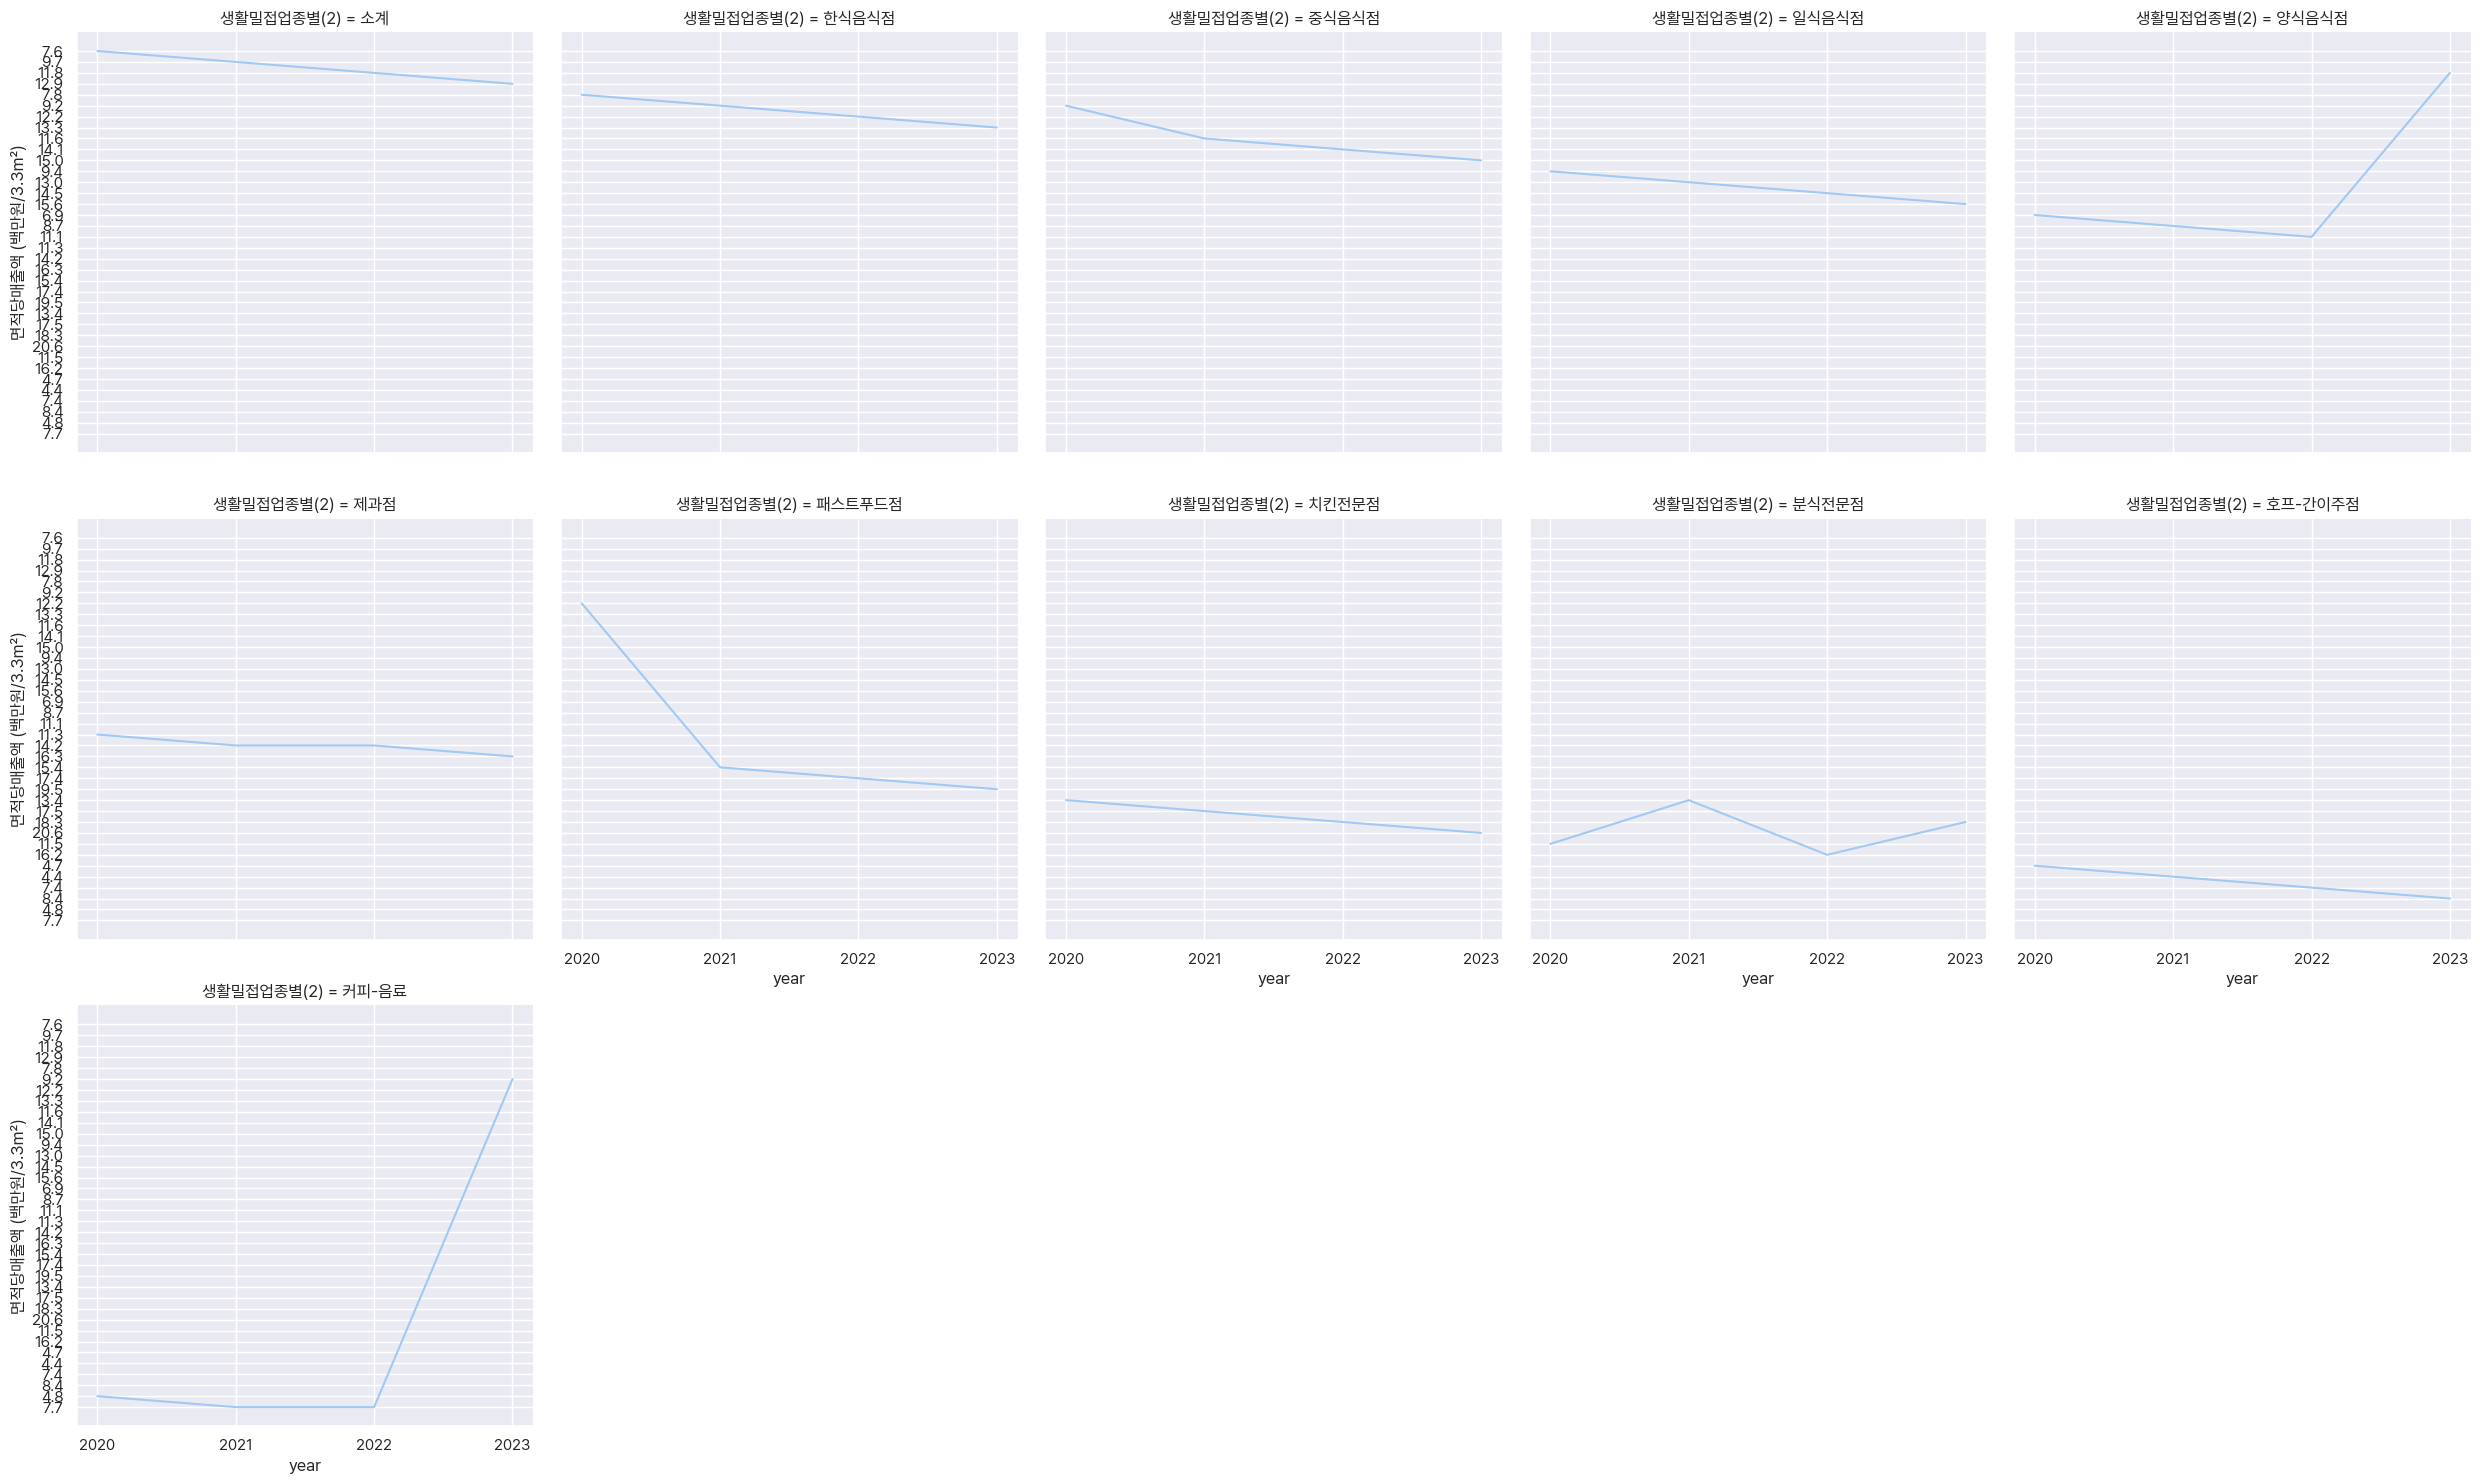

In [116]:
# 외식업 연도별 매출 추이
plt.figure(figsize=(20, 12))
data = ex_df.loc[(ex_df['생활밀접업종별(1)']=='외식업')]
sns.relplot(data=data, x='year', y='면적당매출액 (백만원/3.3㎡)', col='생활밀접업종별(2)', kind='line', col_wrap=5)
plt.xticks(range(2020, 2024))
plt.show()

<Figure size 2000x1200 with 0 Axes>

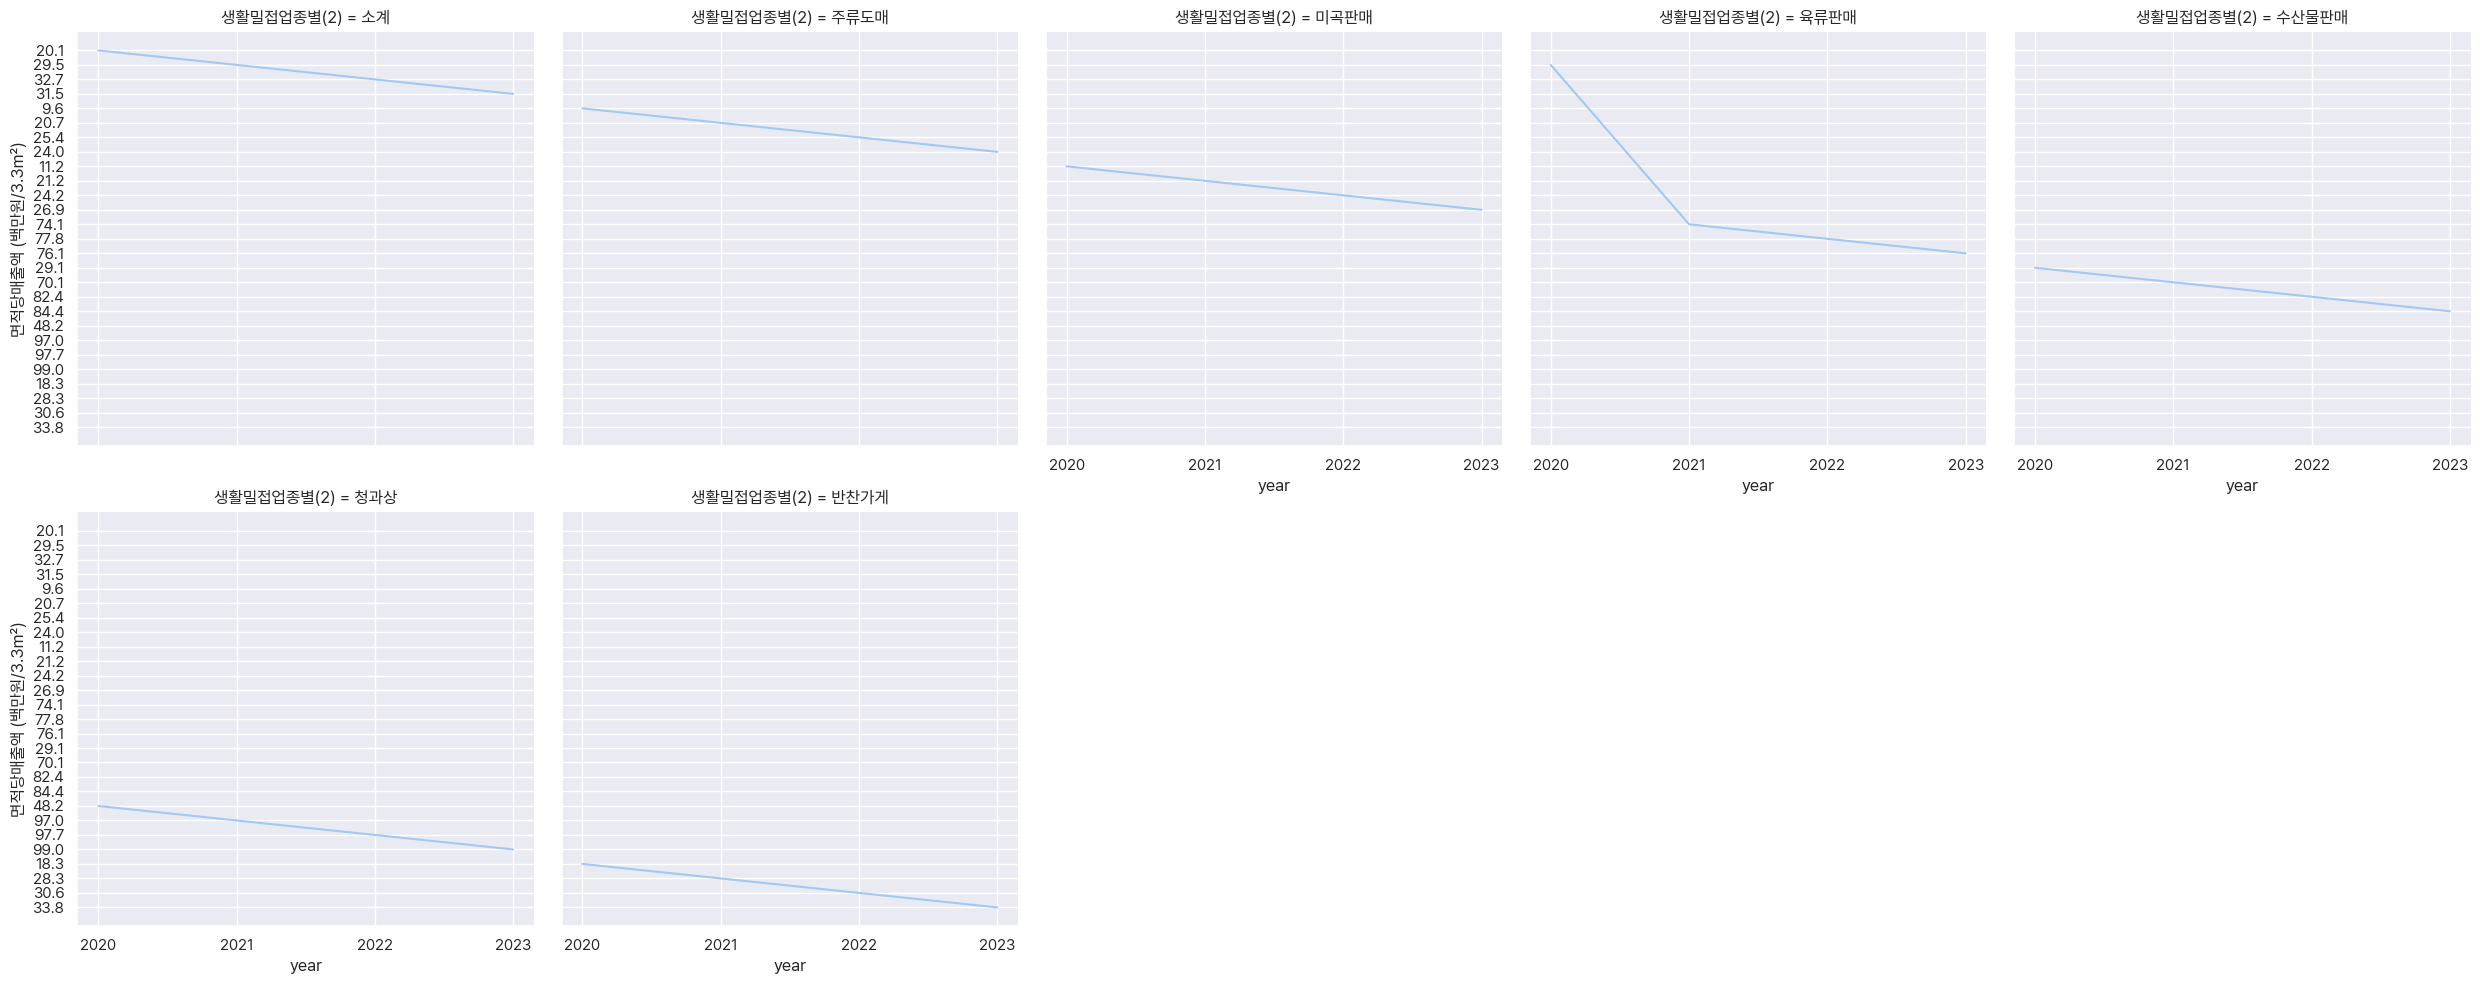

In [117]:
# 소매업 연도별 매출 추이
plt.figure(figsize=(20, 12))
data = ex_df.loc[(ex_df['생활밀접업종별(1)']=='소매업')]
sns.relplot(data=data, x='year', y='면적당매출액 (백만원/3.3㎡)', col='생활밀접업종별(2)', kind='line', col_wrap=5)
plt.xticks(range(2020, 2024))
plt.show()